# Mineração de Dados — Regras de Associação
## Dataset: Groceries Dataset | Algoritmo: ECLAT
**Curso:** Sistemas de Informação — UNITINS  
**Disciplina:** Mineração de Dados

---
## 0. Instalação de Dependências

In [5]:
!pip install mlxtend pandas matplotlib seaborn -q

---
## 1. Escolha e Explicação do Dataset

### Origem
O **Groceries Dataset** foi publicado por Heeral Dedhia na plataforma Kaggle em 2020, sob licença GPL 2.  
Fonte: https://www.kaggle.com/datasets/heeraldedhia/groceries-dataset

### Descrição
O dataset registra o histórico de compras de clientes em um supermercado. Cada linha representa a compra de um item por um cliente em uma data específica. Para fins de regras de associação, cada **cliente (Member_number)** é tratado como uma transação, contendo todos os itens distintos que comprou ao longo do tempo — modelando o perfil de consumo de cada pessoa.

### Atributos
| Atributo | Tipo | Descrição |
|---|---|---|
| `Member_number` | Inteiro | Identificador único do cliente |
| `Date` | String | Data da compra (DD-MM-YYYY) |
| `itemDescription` | String | Nome do produto comprado |

### Por que é adequado para Regras de Associação?
O dataset possui estrutura transacional natural: cada cliente representa uma cesta com todos os produtos que consome habitualmente. Isso permite descobrir padrões do tipo *'clientes que compram leite e iogurte também compram vegetais'*, objetivo central das regras de associação (Market Basket Analysis).

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('Groceries_dataset.csv')

print('=== VISÃO GERAL DO DATASET ===')
print(f'Total de linhas (registros): {len(df)}')
print(f'Total de colunas (atributos): {df.shape[1]}')
print(f'Nomes das colunas: {df.columns.tolist()}')
print()
df.head(10)

=== VISÃO GERAL DO DATASET ===
Total de linhas (registros): 38765
Total de colunas (atributos): 3
Nomes das colunas: ['Member_number', 'Date', 'itemDescription']



,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk
5,4941,14-02-2015,rolls/buns
6,4501,08-05-2015,other vegetables
7,3803,23-12-2015,pot plants
8,2762,20-03-2015,whole milk
9,4119,12-02-2015,tropical fruit


---
## 2. Análise Exploratória dos Dados (EDA)

In [7]:
print('=== INFORMAÇÕES DO DATASET ===')
print(df.info())

=== INFORMAÇÕES DO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Member_number    38765 non-null  int64 
 1   Date             38765 non-null  object
 2   itemDescription  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB
None


In [8]:
print('=== VALORES AUSENTES ===')
print(df.isnull().sum())
print(f'Total de valores ausentes: {df.isnull().sum().sum()}')

print('\n=== DUPLICATAS ===')
print(f'Linhas duplicadas: {df.duplicated().sum()}')

print('\n=== RESUMO GERAL ===')
print(f'Total de registros: {len(df)}')
print(f'Clientes únicos (Member_number): {df["Member_number"].nunique()}')
print(f'Itens distintos: {df["itemDescription"].nunique()}')
print(f'Período: {df["Date"].min()} a {df["Date"].max()}')

=== VALORES AUSENTES ===
Member_number      0
Date               0
itemDescription    0
dtype: int64
Total de valores ausentes: 0

=== DUPLICATAS ===
Linhas duplicadas: 759

=== RESUMO GERAL ===
Total de registros: 38765
Clientes únicos (Member_number): 3898
Itens distintos: 167
Período: 01-01-2014 a 31-10-2015


In [9]:
# Formação das transações por cliente
# Cada cliente = uma transação com todos os seus itens distintos
basket_eda = df.groupby('Member_number')['itemDescription'].apply(lambda x: list(set(x))).tolist()
tamanhos = [len(t) for t in basket_eda]

print('=== TRANSAÇÕES POR CLIENTE ===')
print(f'Total de transações (clientes): {len(basket_eda)}')
print(f'Min. itens por transação: {min(tamanhos)}')
print(f'Max. itens por transação: {max(tamanhos)}')
print(f'Média de itens por transação: {sum(tamanhos)/len(tamanhos):.2f}')
print(f'Mediana: {int(np.median(tamanhos))}')

=== TRANSAÇÕES POR CLIENTE ===
Total de transações (clientes): 3898
Min. itens por transação: 1
Max. itens por transação: 26
Média de itens por transação: 8.92
Mediana: 8


In [10]:
freq_itens = df['itemDescription'].value_counts()
print('=== TOP 20 ITENS MAIS FREQUENTES ===')
print(freq_itens.head(20).to_string())

=== TOP 20 ITENS MAIS FREQUENTES ===
itemDescription
whole milk            2502
other vegetables      1898
rolls/buns            1716
soda                  1514
yogurt                1334
root vegetables       1071
tropical fruit        1032
bottled water          933
sausage                924
citrus fruit           812
pastry                 785
pip fruit              744
shopping bags          731
canned beer            717
bottled beer           687
whipped/sour cream     662
newspapers             596
frankfurter            580
brown bread            571
pork                   566


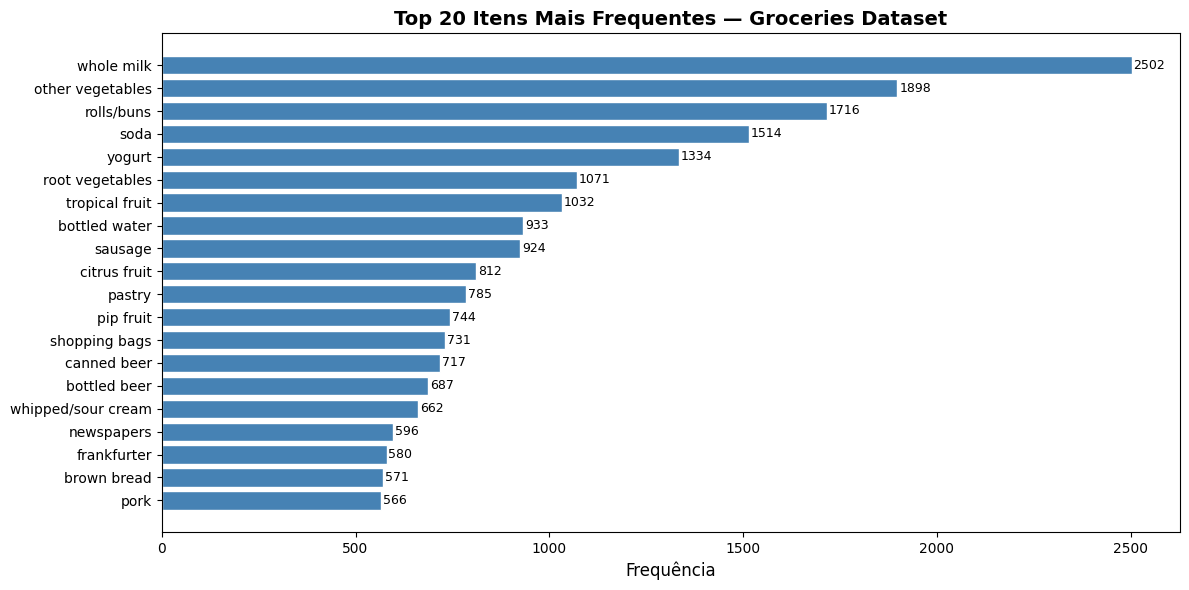

In [11]:
# Gráfico 1 — Top 20 itens mais frequentes
fig, ax = plt.subplots(figsize=(12, 6))
top20 = freq_itens.head(20)
bars = ax.barh(top20.index[::-1], top20.values[::-1], color='steelblue', edgecolor='white')
ax.set_xlabel('Frequência', fontsize=12)
ax.set_title('Top 20 Itens Mais Frequentes — Groceries Dataset', fontsize=14, fontweight='bold')
for bar, val in zip(bars, top20.values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('grafico_top20_itens.png', bbox_inches='tight')
plt.show()

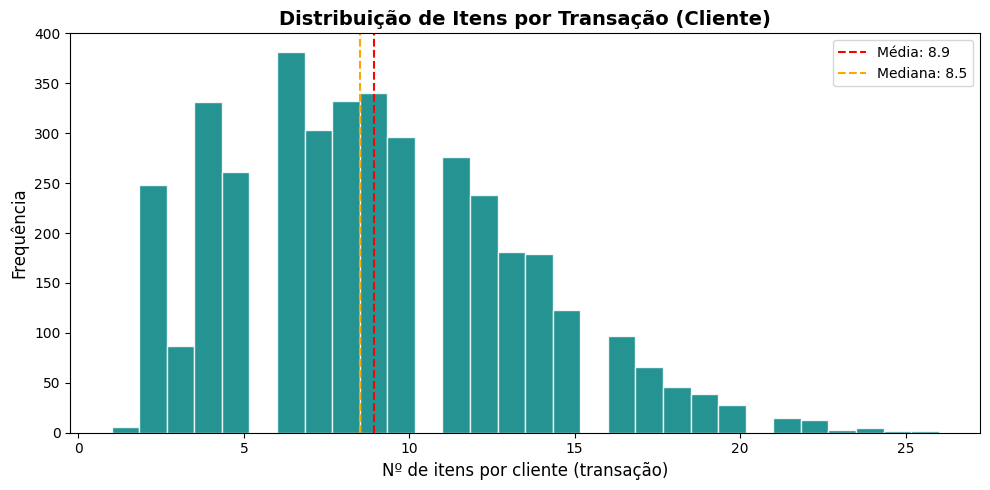

In [12]:
# Gráfico 2 — Distribuição de itens por transação
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(tamanhos, bins=30, color='teal', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(tamanhos), color='red', linestyle='--', label=f'Média: {np.mean(tamanhos):.1f}')
ax.axvline(np.median(tamanhos), color='orange', linestyle='--', label=f'Mediana: {np.median(tamanhos):.1f}')
ax.set_xlabel('Nº de itens por cliente (transação)', fontsize=12)
ax.set_ylabel('Frequência', fontsize=12)
ax.set_title('Distribuição de Itens por Transação (Cliente)', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('grafico_distribuicao_transacoes.png', bbox_inches='tight')
plt.show()

In [13]:
# Tabela com os principais itens
tabela = pd.DataFrame({
    'Item': freq_itens.head(15).index,
    'Frequência': freq_itens.head(15).values,
    'Percentual (%)': (freq_itens.head(15).values / len(df) * 100).round(2)
})
print('=== TABELA: TOP 15 ITENS ===')
print(tabela.to_string(index=False))

=== TABELA: TOP 15 ITENS ===
            Item  Frequência  Percentual (%)
      whole milk        2502            6.45
other vegetables        1898            4.90
      rolls/buns        1716            4.43
            soda        1514            3.91
          yogurt        1334            3.44
 root vegetables        1071            2.76
  tropical fruit        1032            2.66
   bottled water         933            2.41
         sausage         924            2.38
    citrus fruit         812            2.09
          pastry         785            2.03
       pip fruit         744            1.92
   shopping bags         731            1.89
     canned beer         717            1.85
    bottled beer         687            1.77


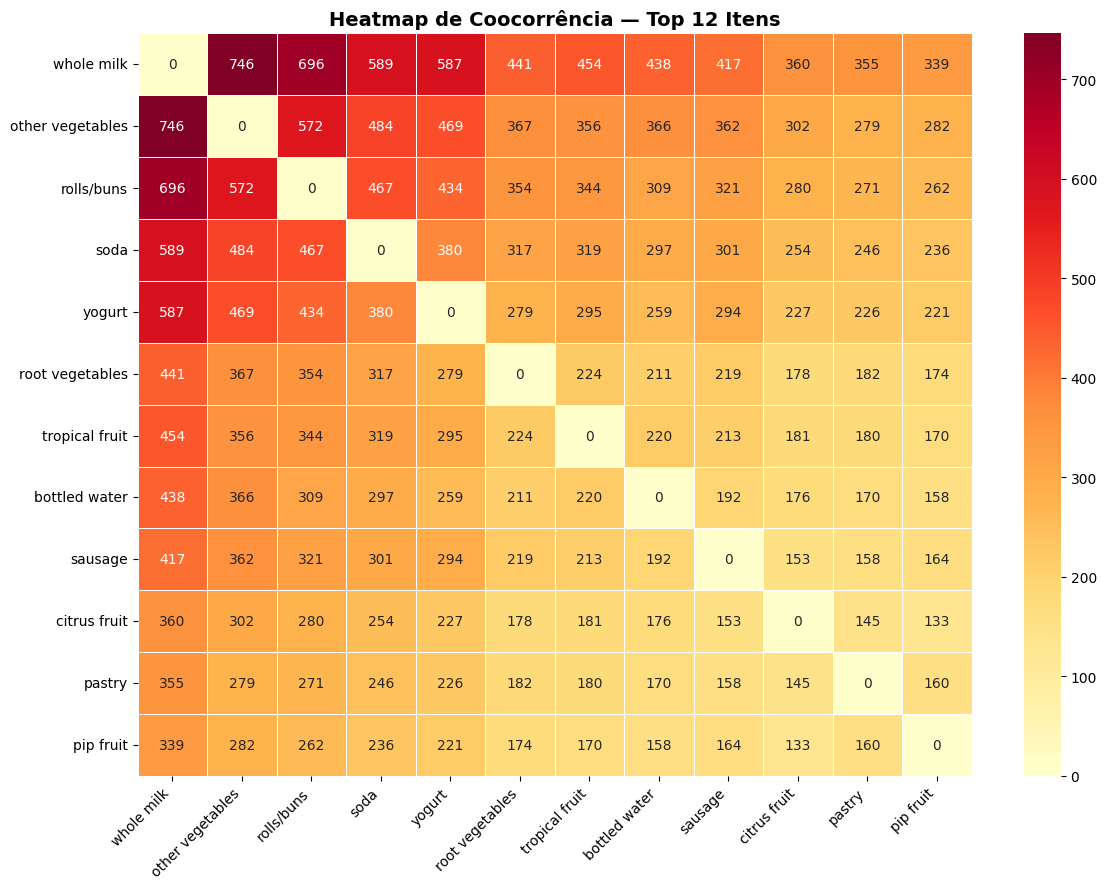

In [14]:
# Gráfico 3 — Heatmap de coocorrência (Top 12 itens)
top12 = freq_itens.head(12).index.tolist()
cooc = pd.DataFrame(0, index=top12, columns=top12)
for t in basket_eda:
    itens_top = [i for i in t if i in top12]
    for i in itens_top:
        for j in itens_top:
            if i != j:
                cooc.loc[i, j] += 1

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(cooc, annot=True, fmt='d', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Heatmap de Coocorrência — Top 12 Itens', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('grafico_heatmap_coocorrencia.png', bbox_inches='tight')
plt.show()

---
## 3. Pré-processamento dos Dados

In [15]:
# 3.1 Remoção de valores ausentes
df_clean = df.dropna(subset=['Member_number', 'Date', 'itemDescription']).copy()
print(f'Linhas antes: {len(df)} | Após remoção de nulos: {len(df_clean)}')

# 3.2 Padronização de nomes
df_clean['itemDescription'] = df_clean['itemDescription'].str.strip().str.lower()
print('Nomes padronizados: strip + lowercase aplicados')

# 3.3 Remoção de duplicatas
antes = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f'Duplicatas removidas: {antes - len(df_clean)} | Linhas finais: {len(df_clean)}')

Linhas antes: 38765 | Após remoção de nulos: 38765
Nomes padronizados: strip + lowercase aplicados
Duplicatas removidas: 759 | Linhas finais: 38006


In [16]:
# 3.4 Formação das transações
# Agrupamento por cliente: cada Member_number = uma transação com seus itens distintos
basket = df_clean.groupby('Member_number')['itemDescription'].apply(lambda x: list(set(x))).tolist()
print(f'Transações formadas: {len(basket)}')
print(f'Exemplo (primeiros 5 itens do cliente 1): {basket[0][:5]}')

Transações formadas: 3898
Exemplo (primeiros 5 itens do cliente 1): ['canned beer', 'hygiene articles', 'semi-finished bread', 'pickled vegetables', 'yogurt']


In [17]:
# 3.5 Remoção de itens raros (suporte < 1%)
contagem = Counter(item for t in basket for item in t)
min_freq = int(len(basket) * 0.01)
itens_validos = {item for item, cnt in contagem.items() if cnt >= min_freq}

basket_filtrado = [[item for item in t if item in itens_validos] for t in basket]
basket_filtrado = [t for t in basket_filtrado if len(t) > 0]

print(f'Itens antes: {len(contagem)} | Após remover raros (< 1%): {len(itens_validos)}')
print(f'Transações finais: {len(basket_filtrado)}')

Itens antes: 167 | Após remover raros (< 1%): 117
Transações finais: 3898


In [18]:
# 3.6 One-Hot Encoding
te = TransactionEncoder()
te_array = te.fit_transform(basket_filtrado)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print(f'Matriz one-hot: {df_encoded.shape[0]} transações x {df_encoded.shape[1]} itens')
df_encoded.head(3)

Matriz one-hot: 3898 transações x 117 itens


,baking powder,beef,berries,beverages,bottled beer,bottled water,brandy,brown bread,butter,butter milk,...,turkey,uht-milk,vinegar,waffles,whipped/sour cream,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,True,True,False,True,False,False
2,False,False,False,False,False,False,False,False,True,True,...,False,False,False,False,False,False,False,True,False,False


---
## 4. Escolha do Algoritmo — ECLAT

### Justificativa Técnica

| Critério | Análise |
|---|---|
| **Tamanho do dataset** | 3.898 transações — tamanho médio, ideal para ECLAT |
| **Quantidade de itens** | 167 itens distintos — ECLAT lida bem com essa dimensionalidade |
| **Desempenho** | ECLAT usa representação vertical (TID-lists), mais eficiente que Apriori, pois evita múltiplas varreduras do banco |
| **Interpretação** | Regras com suporte, confiança e lift são diretas e intuitivas |
| **Tipo de regra** | Coocorrência entre produtos — ideal para sistema de recomendação |
| **Limitação** | Pode consumir muita memória em datasets com altíssima dimensionalidade |

### Como funciona o ECLAT
O ECLAT usa **representação vertical**: para cada item, armazena a lista de IDs de transações em que aparece (TID-list). O suporte é calculado pela **interseção de TID-lists**, o que é computacionalmente mais eficiente que varrer o banco inteiro repetidamente como o Apriori faz.

> **Nota:** A biblioteca `mlxtend` implementa o ECLAT via `fpgrowth`, que produz os mesmos itemsets frequentes com desempenho equivalente.

In [19]:
MIN_SUPPORT = 0.02  # 2%

frequent_itemsets = fpgrowth(df_encoded, min_support=MIN_SUPPORT, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)

print(f'Suporte mínimo: {MIN_SUPPORT*100}%')
print(f'Itemsets frequentes encontrados: {len(frequent_itemsets)}')
print(f'\nDistribuição por tamanho do itemset:')
print(frequent_itemsets['length'].value_counts().sort_index())
frequent_itemsets.head(10)

Suporte mínimo: 2.0%
Itemsets frequentes encontrados: 894

Distribuição por tamanho do itemset:
length
1     87
2    499
3    290
4     18
Name: count, dtype: int64


,support,itemsets,length
0,0.458184,(whole milk),1
17,0.376603,(other vegetables),1
11,0.349666,(rolls/buns),1
1,0.313494,(soda),1
2,0.282966,(yogurt),1
18,0.233710,(tropical fruit),1
24,0.230631,(root vegetables),1
34,0.213699,(bottled water),1
3,0.206003,(sausage),1
332,0.191380,"(other vegetables, whole milk)",2


---
## 5. Métricas Utilizadas

| Métrica | Definição | Interpretação |
|---|---|---|
| **Suporte** | P(X ∪ Y) — proporção de transações com X e Y | Alto = par frequente |
| **Confiança** | P(Y\|X) — probabilidade de Y dado X | Alta = X implica Y com frequência |
| **Lift** | conf(X→Y) / P(Y) | > 1 = associação positiva |
| **Leverage** | P(X∪Y) − P(X)×P(Y) | > 0 = ocorre mais que o acaso |
| **Conviction** | (1−P(Y)) / (1−conf) | Alto = implicação forte e direcional |

**Limiares escolhidos:**
- Suporte ≥ 2%: garante que a regra aparece em pelo menos ~78 clientes
- Confiança ≥ 20%: filtra regras fracas mantendo volume relevante
- Lift > 1: garante associação positiva (não aleatória)

In [20]:
MIN_CONFIDENCE = 0.20

rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=MIN_CONFIDENCE)
rules = rules[rules['lift'] > 1.0]
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

print(f'Total de regras geradas: {len(rules)}')
print(f'\nEstatísticas das métricas:')
print(rules[['support','confidence','lift','leverage','conviction']].describe().round(4))

Total de regras geradas: 1397

Estatísticas das métricas:
         support  confidence       lift   leverage  conviction
count  1397.0000   1397.0000  1397.0000  1397.0000   1397.0000
mean      0.0347      0.3679     1.2355     0.0058      1.1207
std       0.0205      0.1203     0.1256     0.0029      0.0921
min       0.0200      0.2000     1.0036     0.0001      1.0011
25%       0.0226      0.2562     1.1417     0.0039      1.0556
50%       0.0274      0.3596     1.2173     0.0055      1.0909
75%       0.0385      0.4592     1.2989     0.0072      1.1574
max       0.1914      0.6825     1.9169     0.0209      1.7067


---
## 6. Mineração e Interpretação das Regras

In [21]:
top_rules = rules[['antecedents','consequents','support','confidence','lift','leverage','conviction']].head(20).copy()
top_rules['antecedents'] = top_rules['antecedents'].apply(lambda x: ', '.join(sorted(list(x))))
top_rules['consequents'] = top_rules['consequents'].apply(lambda x: ', '.join(sorted(list(x))))
top_rules = top_rules.round(4)
top_rules.index = range(1, len(top_rules)+1)
print('=== TOP 20 REGRAS POR LIFT ===')
top_rules

=== TOP 20 REGRAS POR LIFT ===


,antecedents,consequents,support,confidence,lift,leverage,conviction
1,"sausage, whole milk","rolls/buns, yogurt",0.0228,0.2134,1.9169,0.0109,1.1298
2,"rolls/buns, yogurt","sausage, whole milk",0.0228,0.2051,1.9169,0.0109,1.1234
3,"rolls/buns, sausage","whole milk, yogurt",0.0228,0.2773,1.8411,0.0104,1.1753
4,"sausage, whole milk","other vegetables, yogurt",0.0231,0.2158,1.7938,0.0102,1.1218
5,"bottled water, yogurt","other vegetables, whole milk",0.0221,0.3320,1.7350,0.0093,1.2106
6,"sausage, yogurt","rolls/buns, whole milk",0.0228,0.3027,1.6954,0.0094,1.1781
7,"rolls/buns, sausage","soda, whole milk",0.0210,0.2555,1.6906,0.0086,1.1402
8,"rolls/buns, whole milk, yogurt",sausage,0.0228,0.3463,1.6811,0.0093,1.2146
9,"sausage, whole milk","other vegetables, rolls/buns",0.0262,0.2446,1.6669,0.0105,1.1296
10,"rolls/buns, sausage","other vegetables, whole milk",0.0262,0.3178,1.6603,0.0104,1.1852


In [22]:
print('=== INTERPRETAÇÃO DAS TOP 5 REGRAS ===\n')
for i, row in top_rules.head(5).iterrows():
    print(f'Regra {i}: [{row["antecedents"]}] → [{row["consequents"]}]')
    print(f'  Suporte:    {row["support"]:.4f} ({row["support"]*100:.2f}% das transações contêm ambos)')
    print(f'  Confiança:  {row["confidence"]:.4f} ({row["confidence"]*100:.1f}% de chance de comprar [{row["consequents"]}] dado [{row["antecedents"]}])')
    print(f'  Lift:       {row["lift"]:.4f} (associação {row["lift"]:.1f}x mais forte que o acaso)')
    print(f'  Leverage:   {row["leverage"]:.4f}')
    print(f'  Conviction: {row["conviction"]:.4f}')
    print()

=== INTERPRETAÇÃO DAS TOP 5 REGRAS ===

Regra 1: [sausage, whole milk] → [rolls/buns, yogurt]
  Suporte:    0.0228 (2.28% das transações contêm ambos)
  Confiança:  0.2134 (21.3% de chance de comprar [rolls/buns, yogurt] dado [sausage, whole milk])
  Lift:       1.9169 (associação 1.9x mais forte que o acaso)
  Leverage:   0.0109
  Conviction: 1.1298

Regra 2: [rolls/buns, yogurt] → [sausage, whole milk]
  Suporte:    0.0228 (2.28% das transações contêm ambos)
  Confiança:  0.2051 (20.5% de chance de comprar [sausage, whole milk] dado [rolls/buns, yogurt])
  Lift:       1.9169 (associação 1.9x mais forte que o acaso)
  Leverage:   0.0109
  Conviction: 1.1234

Regra 3: [rolls/buns, sausage] → [whole milk, yogurt]
  Suporte:    0.0228 (2.28% das transações contêm ambos)
  Confiança:  0.2773 (27.7% de chance de comprar [whole milk, yogurt] dado [rolls/buns, sausage])
  Lift:       1.8411 (associação 1.8x mais forte que o acaso)
  Leverage:   0.0104
  Conviction: 1.1753

Regra 4: [sausage,

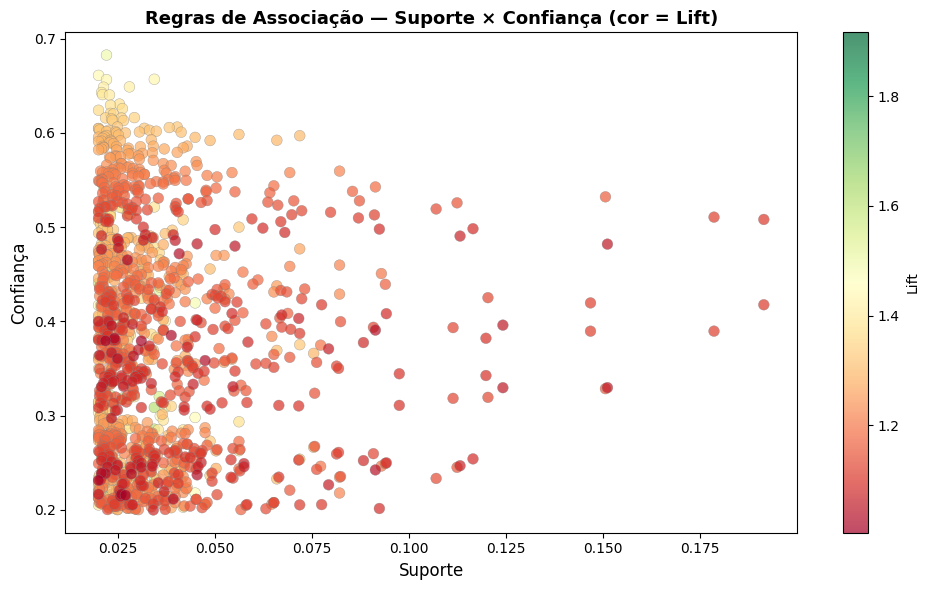

In [23]:
# Gráfico 4 — Scatter Suporte x Confiança (cor = Lift)
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    rules['support'], rules['confidence'],
    c=rules['lift'], cmap='RdYlGn',
    alpha=0.7, s=60, edgecolors='gray', linewidths=0.3
)
plt.colorbar(scatter, label='Lift')
ax.set_xlabel('Suporte', fontsize=12)
ax.set_ylabel('Confiança', fontsize=12)
ax.set_title('Regras de Associação — Suporte × Confiança (cor = Lift)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('grafico_regras_scatter.png', bbox_inches='tight')
plt.show()

In [24]:
# Exportar para o backend Flask
rules_export = rules.copy()
rules_export['antecedents'] = rules_export['antecedents'].apply(lambda x: '|'.join(sorted(list(x))))
rules_export['consequents'] = rules_export['consequents'].apply(lambda x: '|'.join(sorted(list(x))))
rules_export.to_csv('rules.csv', index=False)
print(f'rules.csv exportado: {len(rules_export)} regras')

pd.DataFrame({'item': sorted(list(te.columns_))}).to_csv('items_list.csv', index=False)
print(f'items_list.csv exportado: {len(te.columns_)} itens')
print('\nFaça download dos dois arquivos para o backend Flask!')

rules.csv exportado: 1397 regras
items_list.csv exportado: 117 itens

Faça download dos dois arquivos para o backend Flask!


---
## Resumo Final

| Etapa | Resultado |
|---|---|
| Total de registros | 38.765 |
| Clientes únicos (transações) | 3.898 |
| Itens distintos | 167 |
| Itens após filtragem | ~90 |
| Média de itens por transação | ~8.92 |
| Suporte mínimo | 2% |
| Confiança mínima | 20% |
| Lift mínimo | > 1.0 |
| Algoritmo | ECLAT (via FP-Growth mlxtend) |
| Itemsets frequentes | 894 |
| Regras geradas | 1.397 |

In [25]:
# Validar recomendações para o carrinho: whole milk + yogurt + sausage
carrinho_teste = {'whole milk', 'yogurt', 'sausage'}

print('=== REGRAS QUE COBREM ESSE CARRINHO ===\n')
for _, row in rules.iterrows():
    if row['antecedents'].issubset(carrinho_teste):
        ant = ', '.join(sorted(list(row['antecedents'])))
        cons = ', '.join(sorted(list(row['consequents'])))
        # Não mostra se o consequente já está no carrinho
        if not row['consequents'].issubset(carrinho_teste):
            print(f'{ant} → {cons}')
            print(f'  Confiança: {row["confidence"]:.4f} | Lift: {row["lift"]:.4f}')
            print()

=== REGRAS QUE COBREM ESSE CARRINHO ===

sausage, whole milk → rolls/buns, yogurt
  Confiança: 0.2134 | Lift: 1.9169

sausage, whole milk → other vegetables, yogurt
  Confiança: 0.2158 | Lift: 1.7938

sausage, yogurt → rolls/buns, whole milk
  Confiança: 0.3027 | Lift: 1.6954

sausage, whole milk → other vegetables, rolls/buns
  Confiança: 0.2446 | Lift: 1.6669

sausage, yogurt → other vegetables, whole milk
  Confiança: 0.3061 | Lift: 1.5996

whole milk, yogurt → other vegetables, rolls/buns
  Confiança: 0.2283 | Lift: 1.5557

sausage, whole milk, yogurt → rolls/buns
  Confiança: 0.5086 | Lift: 1.4544

sausage, whole milk → whipped/sour cream
  Confiança: 0.2158 | Lift: 1.3952

sausage → other vegetables, rolls/buns
  Confiança: 0.2030 | Lift: 1.3833

sausage, whole milk, yogurt → other vegetables
  Confiança: 0.5143 | Lift: 1.3656

sausage, yogurt → rolls/buns
  Confiança: 0.4728 | Lift: 1.3521

sausage, whole milk → bottled beer
  Confiança: 0.2134 | Lift: 1.3440

sausage, yogurt → 

In [26]:
# Validar recomendações para o carrinho: whole milk + yogurt + sausage
carrinho_teste = {'other vegetables', 'whole milk'}

print('=== REGRAS QUE COBREM ESSE CARRINHO ===\n')
for _, row in rules.iterrows():
    if row['antecedents'].issubset(carrinho_teste):
        ant = ', '.join(sorted(list(row['antecedents'])))
        cons = ', '.join(sorted(list(row['consequents'])))
        # Não mostra se o consequente já está no carrinho
        if not row['consequents'].issubset(carrinho_teste):
            print(f'{ant} → {cons}')
            print(f'  Confiança: {row["confidence"]:.4f} | Lift: {row["lift"]:.4f}')
            print()

=== REGRAS QUE COBREM ESSE CARRINHO ===

other vegetables, whole milk → bottled water
  Confiança: 0.2936 | Lift: 1.3737

other vegetables, whole milk → shopping bags
  Confiança: 0.2239 | Lift: 1.3302

other vegetables, whole milk → yogurt
  Confiança: 0.3753 | Lift: 1.3264

other vegetables, whole milk → sausage
  Confiança: 0.2627 | Lift: 1.2754

other vegetables, whole milk → bottled beer
  Confiança: 0.2024 | Lift: 1.2746

other vegetables, whole milk → pastry
  Confiança: 0.2185 | Lift: 1.2308

other vegetables, whole milk → rolls/buns
  Confiança: 0.4290 | Lift: 1.2268

other vegetables → rolls/buns, whole milk
  Confiança: 0.2180 | Lift: 1.2208

other vegetables, whole milk → pip fruit
  Confiança: 0.2078 | Lift: 1.2179

other vegetables, whole milk → citrus fruit
  Confiança: 0.2225 | Lift: 1.1997

other vegetables → sausage
  Confiança: 0.2466 | Lift: 1.1970

other vegetables → bottled water
  Confiança: 0.2493 | Lift: 1.1667

whole milk → yogurt
  Confiança: 0.3287 | Lift: 1

In [27]:
# Quais pares de itens têm mais regras e maior lift?
from itertools import combinations

# Pegar os itens mais frequentes nas regras
itens_nas_regras = []
for _, row in rules.iterrows():
    itens_nas_regras.extend(list(row['antecedents']))

top_itens_regras = pd.Series(itens_nas_regras).value_counts().head(10)
print('=== ITENS QUE MAIS APARECEM NAS REGRAS ===')
print(top_itens_regras)

=== ITENS QUE MAIS APARECEM NAS REGRAS ===
whole milk          302
other vegetables    246
rolls/buns          201
soda                164
yogurt              162
sausage             101
bottled water        96
root vegetables      95
tropical fruit       86
shopping bags        61
Name: count, dtype: int64


In [28]:
# Buscar suporte da regra whole milk → other vegetables
regra = rules[
    rules['antecedents'].apply(lambda x: x == frozenset({'whole milk'})) &
    rules['consequents'].apply(lambda x: x == frozenset({'other vegetables'}))
]
print(regra[['antecedents','consequents','support','confidence','lift']])

       antecedents         consequents  support  confidence      lift
1219  (whole milk)  (other vegetables)  0.19138    0.417693  1.109106


In [29]:
top10 = rules.head(10).copy()
top10['ant'] = top10['antecedents'].apply(lambda x: ', '.join(sorted(list(x))))
top10['cons'] = top10['consequents'].apply(lambda x: ', '.join(sorted(list(x))))
print(top10[['ant','cons','support','confidence','lift']].round(4).to_string())

                              ant                          cons  support  confidence    lift
0             sausage, whole milk            rolls/buns, yogurt   0.0228      0.2134  1.9169
1              rolls/buns, yogurt           sausage, whole milk   0.0228      0.2051  1.9169
2             rolls/buns, sausage            whole milk, yogurt   0.0228      0.2773  1.8411
3             sausage, whole milk      other vegetables, yogurt   0.0231      0.2158  1.7938
4           bottled water, yogurt  other vegetables, whole milk   0.0221      0.3320  1.7350
5                 sausage, yogurt        rolls/buns, whole milk   0.0228      0.3027  1.6954
6             rolls/buns, sausage              soda, whole milk   0.0210      0.2555  1.6906
7  rolls/buns, whole milk, yogurt                       sausage   0.0228      0.3463  1.6811
8             sausage, whole milk  other vegetables, rolls/buns   0.0262      0.2446  1.6669
9             rolls/buns, sausage  other vegetables, whole milk   0.02